# The EM Algorithm for Gaussian Mixtures
**Course:** Machine Learning (20.IDI12) · **Mentor:** Prof. Branimir Todorović · **Author:** Elvir Muslić

This notebook accompanies the seminar paper *The EM Algorithm for Gaussian Mixtures*. It has three parts.

1. **One iteration by hand (Section 5 of the paper).** The E-step (7) and the M-step (9) are computed with NumPy and SciPy on four points, then compared with one iteration of scikit-learn's `GaussianMixture`.
2. **Old Faithful (Section 6).** `GaussianMixture` fits two Gaussians to the 272 eruptions from a deliberately poor start. It is run one iteration at a time, so that the log-likelihood can be recorded after every iteration.
3. **Random starts and figures.**

Run it in VS Code with the `.venv` kernel (Run All), or from this folder with `.venv/bin/jupyter nbconvert --to notebook --execute --inplace em_project.ipynb`.

In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Ellipse
from scipy.stats import multivariate_normal
from sklearn.exceptions import ConvergenceWarning
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore", category=ConvergenceWarning)   # below, fit() is asked for one iteration at a time on purpose
Path("figures").mkdir(exist_ok=True)

def weighted_densities(X, weights, means, covs):
    # pi_k N(x_i | mu_k, Sigma_k) for every point i (rows) and every component k (columns)
    return np.column_stack([w * multivariate_normal.pdf(X, m, S) for w, m, S in zip(weights, means, covs)])

def log_likelihood(X, weights, means, covs):
    # the log-likelihood (2): the sum over the points of log p(x_i)
    return np.log(weighted_densities(X, weights, means, covs).sum(axis=1)).sum()

## 1. One iteration by hand (Section 5)
Four points in one dimension, $x = (1, 2, 6, 7)$, two components, start $\pi = (\tfrac12, \tfrac12)$, $\mu = (0, 5)$, $\sigma^2 = (1, 1)$.

- **E-step (7):** each point's responsibilities are its weighted densities divided by their sum, so they add up to 1.
- **M-step (9):** $N_k$ is the sum of the responsibilities of component $k$; the new weight is $N_k/n$, the new mean is the responsibility-weighted average of the points, and the new variance is the responsibility-weighted average of the squared distances from the new mean.

The printed values are Table 1 of the paper.

In [2]:
x = np.array([[1.0], [2.0], [6.0], [7.0]])                     # one point per row
weights, means, covs = np.array([0.5, 0.5]), np.array([[0.0], [5.0]]), np.array([[[1.0]], [[1.0]]])

dens = weighted_densities(x, weights, means, covs)
resp = dens / dens.sum(axis=1, keepdims=True)                  # E-step (7): responsibilities, one row per point
N_k = resp.sum(axis=0)                                         # M-step (9)
new_weights = N_k / len(x)
new_means = resp.T @ x / N_k[:, None]
new_vars = (resp * (x - new_means.T) ** 2).sum(axis=0) / N_k

print("x_i  gamma_i1  gamma_i2")
for xi, (g1, g2) in zip(x[:, 0], resp):
    print(f"{xi:3.0f}  {g1:.4f}    {g2:.4f}")
print(f"N_k = {N_k.round(4)}, pi = {new_weights.round(4)}, mu = {new_means[:, 0].round(4)}, sigma^2 = {new_vars.round(4)}")
print(f"log-likelihood: {log_likelihood(x, weights, means, covs):.4f} before the step, "
      f"{log_likelihood(x, new_weights, new_means, new_vars[:, None, None]):.4f} after")

x_i  gamma_i1  gamma_i2
  1  0.9994    0.0006
  2  0.9241    0.0759
  6  0.0000    1.0000
  7  0.0000    1.0000
N_k = [1.9236 2.0764], pi = [0.4809 0.5191], mu = [1.4804 6.3341], sigma^2 = [0.2496 0.9611]
log-likelihood: -11.3689 before the step, -6.3155 after


**The same iteration with scikit-learn.** `GaussianMixture` starts from the given weights, means and precisions (inverse covariances); `max_iter=1` makes `fit()` run one E-step and one M-step, and `reg_covar=0` turns off the small number it would otherwise add to every variance. Its result equals the hand computation.

In [3]:
gm = GaussianMixture(2, weights_init=weights, means_init=means, precisions_init=np.linalg.inv(covs), reg_covar=0, max_iter=1).fit(x)
difference = max(abs(gm.weights_ - new_weights).max(), abs(gm.means_[:, 0] - new_means[:, 0]).max(), abs(gm.covariances_.ravel() - new_vars).max())
print(f"scikit-learn after one iteration: pi = {gm.weights_.round(4)}, mu = {gm.means_[:, 0].round(4)}, sigma^2 = {gm.covariances_.ravel().round(4)}; "
      f"largest difference from the hand values {difference:.1e}")

scikit-learn after one iteration: pi = [0.4809 0.5191], mu = [1.4804 6.3341], sigma^2 = [0.2496 0.9611]; largest difference from the hand values 6.2e-15


## 2. Old Faithful (Section 6)
The 272 eruptions (duration and waiting time to the next eruption, in minutes) are standardized: each column is centred at its mean and divided by its standard deviation. EM starts from a deliberately poor guess: equal weights, means at $(-1.5, 1.5)$ and $(1.5, -1.5)$, where there are no points, and identity covariances.

`run_em` keeps one `GaussianMixture` with `warm_start=True` and `max_iter=1`, so every call of `fit()` continues from the current parameters and performs exactly one iteration, an E-step and an M-step. After each call it records the log-likelihood, `score()` times $n$ (`score()` is the mean per point), and it stops when the log-likelihood changes by less than $10^{-10}$.

In [4]:
X_min = np.loadtxt("data/faithful.csv", delimiter=",", skiprows=1)   # 272 rows: eruption duration, waiting time (minutes)
scaler = StandardScaler()
X = scaler.fit_transform(X_min)                                     # standardized: mean 0 and standard deviation 1 per column
start = (np.array([0.5, 0.5]), np.array([[-1.5, 1.5], [1.5, -1.5]]), np.array([np.eye(2), np.eye(2)]))

def run_em(X, weights, means, covs, tol=1e-10, max_iter=1000):
    # EM with scikit-learn, one iteration per fit() call; returns the model, the log-likelihoods and the parameters after every iteration
    gm = GaussianMixture(len(weights), weights_init=weights, means_init=means, precisions_init=np.linalg.inv(covs),
                         reg_covar=0, max_iter=1, warm_start=True)
    logliks, states = [log_likelihood(X, weights, means, covs)], [(weights, means, covs)]
    for _ in range(max_iter):
        gm.fit(X)                                                   # one E-step and one M-step
        logliks.append(gm.score(X) * len(X))
        states.append((gm.weights_, gm.means_, gm.covariances_))
        if abs(logliks[-1] - logliks[-2]) < tol:
            break
    return gm, np.array(logliks), states

gm, ll, states = run_em(X, *start)
t_half = np.argmax(ll >= (ll[1] + ll[-1]) / 2)                      # first iteration past half of the gain left after the first one
print(f"{len(ll) - 1} iterations, log-likelihood {ll[-1]:.4f}; it was {ll[0]:.2f} at the start and {ll[1]:.2f} after one iteration; "
      f"half of the remaining gain at iteration {t_half}; smallest change {np.diff(ll).min():.1e}")
means_min = scaler.inverse_transform(gm.means_)                     # back to minutes
covs_min = gm.covariances_ * np.outer(scaler.scale_, scaler.scale_)
for k in range(2):
    print(f"component {k + 1}: weight {gm.weights_[k]:.3f}, mean {means_min[k].round(2)} min, "
          f"covariance entries {covs_min[k][0, 0]:.3f}, {covs_min[k][0, 1]:.3f}, {covs_min[k][1, 1]:.3f}")

53 iterations, log-likelihood -385.4607; it was -1331.48 at the start and -542.98 after one iteration; half of the remaining gain at iteration 35; smallest change 2.2e-11
component 1: weight 0.356, mean [ 2.04 54.48] min, covariance entries 0.069, 0.435, 33.697
component 2: weight 0.644, mean [ 4.29 79.97] min, covariance entries 0.170, 0.941, 36.046


## 3. Random starts
EM only climbs, so it can stop at a local maximum. Twenty more runs start with the means at two randomly chosen data points, identity covariances and equal weights.

In [5]:
rng = np.random.default_rng(0)
runs = [run_em(X, np.array([0.5, 0.5]), X[rng.choice(len(X), size=2, replace=False)], np.array([np.eye(2), np.eye(2)])) for _ in range(20)]
finals = [r[1][-1] for r in runs]
print(f"final log-likelihoods {np.unique(np.round(finals, 4))}, {min(len(r[1]) for r in runs) - 1} to {max(len(r[1]) for r in runs) - 1} iterations")

final log-likelihoods [-385.4607], 11 to 37 iterations


## 4. Figures
Figure 1 of the paper: the points coloured by their responsibilities (red and blue, purple when shared) with the $2\sigma$ ellipse of each component, at the start, after one and five iterations, and at the end. Figure 2: the log-likelihood for $t \ge 1$ (the start, $t = 0$, is left out for scale).

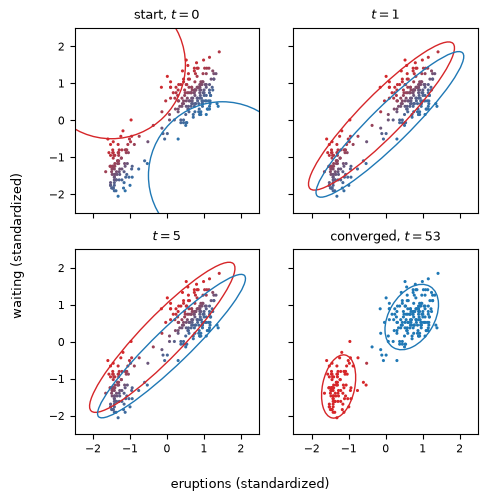

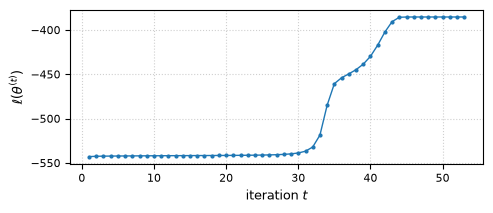

In [6]:
plt.rcParams.update({"font.size": 9, "axes.titlesize": 9, "xtick.labelsize": 8, "ytick.labelsize": 8, "pdf.fonttype": 42})
RED, BLUE = np.array([0.84, 0.15, 0.16]), np.array([0.12, 0.47, 0.71])

def draw_state(ax, weights, means, covs, title):
    dens = weighted_densities(X, weights, means, covs)
    resp = dens / dens.sum(axis=1, keepdims=True)
    ax.scatter(X[:, 0], X[:, 1], c=resp @ [RED, BLUE], s=5, linewidths=0)   # colour of point i: gamma_i1 * RED + gamma_i2 * BLUE
    for k, color in enumerate((RED, BLUE)):
        vals, vecs = np.linalg.eigh(covs[k])                        # the ellipse axes: eigenvalues in ascending order
        angle = np.degrees(np.arctan2(vecs[1, 1], vecs[0, 1]))
        ax.add_patch(Ellipse(means[k], 4 * np.sqrt(vals[1]), 4 * np.sqrt(vals[0]), angle=angle, fill=False, color=color))
    ax.set(title=title, xlim=(-2.5, 2.5), ylim=(-2.5, 2.5), aspect="equal")

fig, axes = plt.subplots(2, 2, figsize=(5.0, 5.0), sharex=True, sharey=True)
for ax, t, title in zip(axes.flat, (0, 1, 5, -1), ("start, $t=0$", "$t=1$", "$t=5$", f"converged, $t={len(ll) - 1}$")):
    draw_state(ax, *states[t], title)
fig.supxlabel("eruptions (standardized)", fontsize=9)
fig.supylabel("waiting (standardized)", fontsize=9)
fig.tight_layout()
fig.savefig("figures/em_iterations.pdf", bbox_inches="tight")

fig, ax = plt.subplots(figsize=(5.0, 2.2))
ax.plot(np.arange(1, len(ll)), ll[1:], "o-", ms=2, lw=1)
ax.set(xlabel="iteration $t$", ylabel=r"$\ell(\theta^{(t)})$")
ax.grid(True, ls=":", alpha=0.6)
fig.tight_layout()
fig.savefig("figures/em_loglik.pdf", bbox_inches="tight")